In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
import os as os

In [2]:
df=pd.read_csv('../data/e-commerce-data.csv',encoding='latin-1')
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,12/1/2010 8:26,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,12/1/2010 8:26,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,12/1/2010 8:34,1.69,13047.0,United Kingdom


In [3]:
df.shape

(541909, 8)

In [4]:
df.dtypes
#invoicedate hay que pasarlo a formato fecha

InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object

In [5]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [6]:
#campos vacios
columns_text=df.select_dtypes(include='str').columns

for col in columns_text:
    field_empty= (df[col].str.strip()=='').sum()
    if field_empty>0:
        print(f'la columa {col} tiene {field_empty} campos vacios')

print("Revision completa")

Revision completa


In [7]:
#filas duplicadas
duplicated_rows=df.duplicated().sum()
if duplicated_rows>0:
    print(f'Hay {duplicated_rows} filas duplicadas')
else:
    print('No hay filas duplicadas')

Hay 5268 filas duplicadas


In [8]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


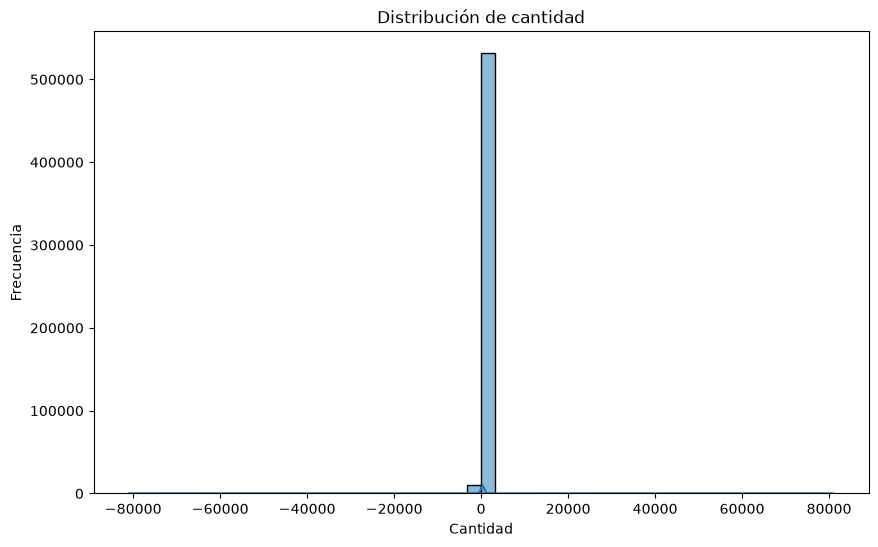

In [9]:
plt.figure(figsize=(10,6))
sns.histplot(df['Quantity'], bins=50, kde=True)   
plt.title('Distribución de cantidad')
plt.xlabel('Cantidad')
plt.ylabel('Frecuencia')
plt.show()
# la inmesa mayoría de las cantidades son positivas, pero hay algunas negativas que podrían indicar devoluciones o errores en los datos.

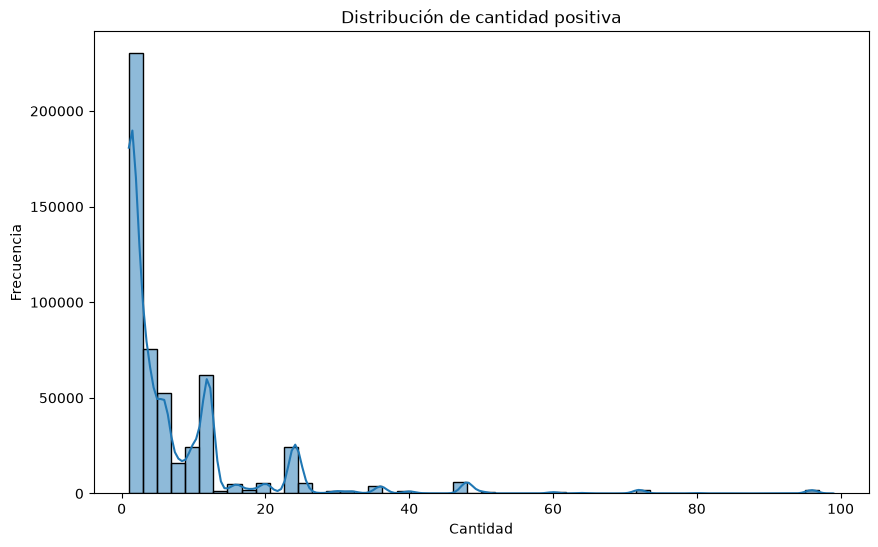

In [10]:
# Datos positivos 
datos_positivos=df[(df['Quantity']>0) & (df['Quantity']<100)]
plt.figure(figsize=(10,6))
sns.histplot(datos_positivos['Quantity'], bins=50, kde=True)   
plt.title('Distribución de cantidad positiva')
plt.xlabel('Cantidad')
plt.ylabel('Frecuencia')
plt.show()




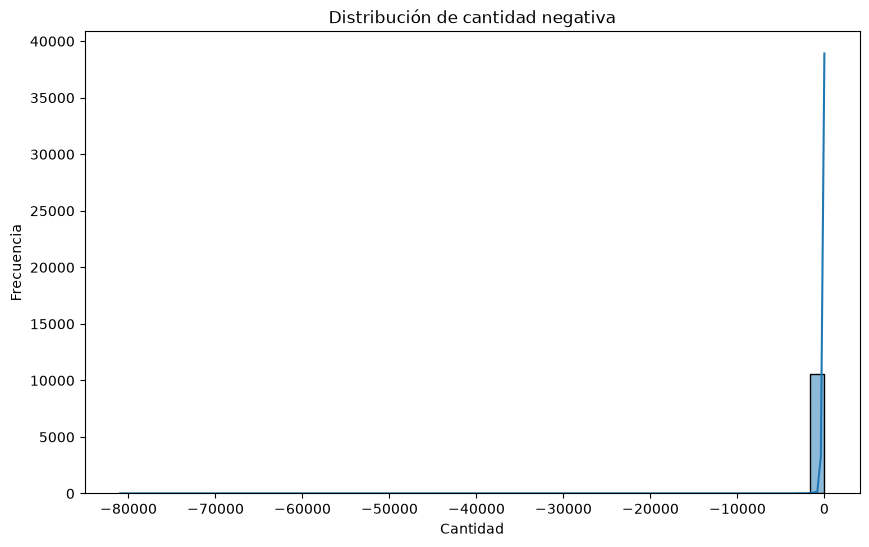

In [12]:
# Devolcuiones o errores
datos_negativos=df[df['Quantity']<0]
plt.figure(figsize=(10,6))
sns.histplot(datos_negativos['Quantity'], bins=50, kde=True)   
plt.title('Distribución de cantidad negativa')
plt.xlabel('Cantidad')
plt.ylabel('Frecuencia')
plt.show()


In [17]:
# Contar cuántas veces aparece cada producto en las devoluciones
top_devoluciones = df[['StockCode', 'Description']].value_counts().head(10)

print("Los 10 productos con más devoluciones son:")
print(top_devoluciones)

Los 10 productos con más devoluciones son:
StockCode  Description                       
85123A     WHITE HANGING HEART T-LIGHT HOLDER    2302
22423      REGENCY CAKESTAND 3 TIER              2200
85099B     JUMBO BAG RED RETROSPOT               2159
47566      PARTY BUNTING                         1727
20725      LUNCH BAG RED RETROSPOT               1638
84879      ASSORTED COLOUR BIRD ORNAMENT         1501
22720      SET OF 3 CAKE TINS PANTRY DESIGN      1473
21212      PACK OF 72 RETROSPOT CAKE CASES       1385
20727      LUNCH BAG  BLACK SKULL.               1350
22457      NATURAL SLATE HEART CHALKBOARD        1280
Name: count, dtype: int64


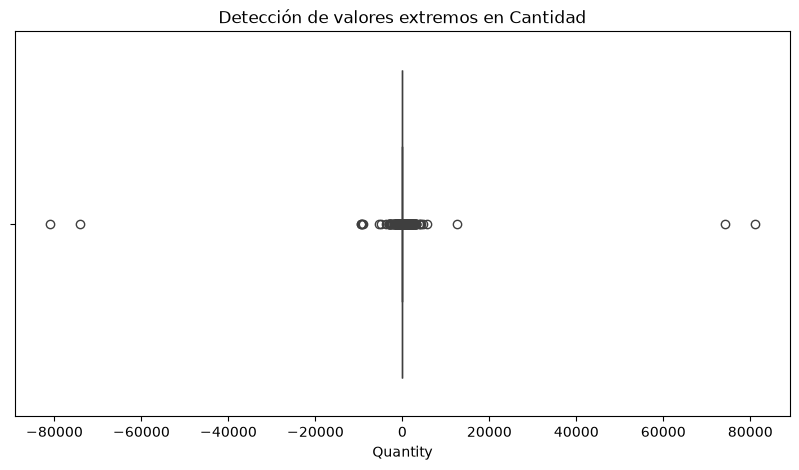

In [20]:
# Detección de valores extremos
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['Quantity'])
plt.title('Detección de valores extremos en Cantidad')
plt.show()



C:\Users\Coders\AppData\Local\Temp\ipykernel_5736\4048393639.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


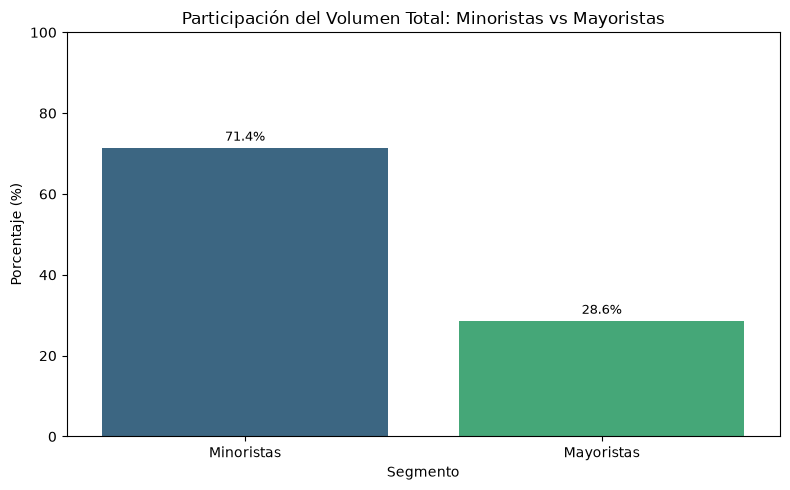

In [38]:
# Separación de segmentos
retail = df[df['Quantity'] <= 100]
mayoristas = df[df['Quantity'] > 100]

# Totales
total_retail = retail['Quantity'].sum()
total_mayoristas = mayoristas['Quantity'].sum()
total_general = total_retail + total_mayoristas

# DataFrame en porcentaje
resumen = pd.DataFrame({
    'Segmento': ['Minoristas', 'Mayoristas'],
    'Porcentaje': [
        total_retail / total_general * 100,
        total_mayoristas / total_general * 100
    ]
})

# Gráfico
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=resumen,
    x='Segmento',
    y='Porcentaje',
    palette='viridis'
)

# Etiquetas en porcentaje
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=9)

plt.title('Participación del Volumen Total: Minoristas vs Mayoristas')
plt.ylabel('Porcentaje (%)')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

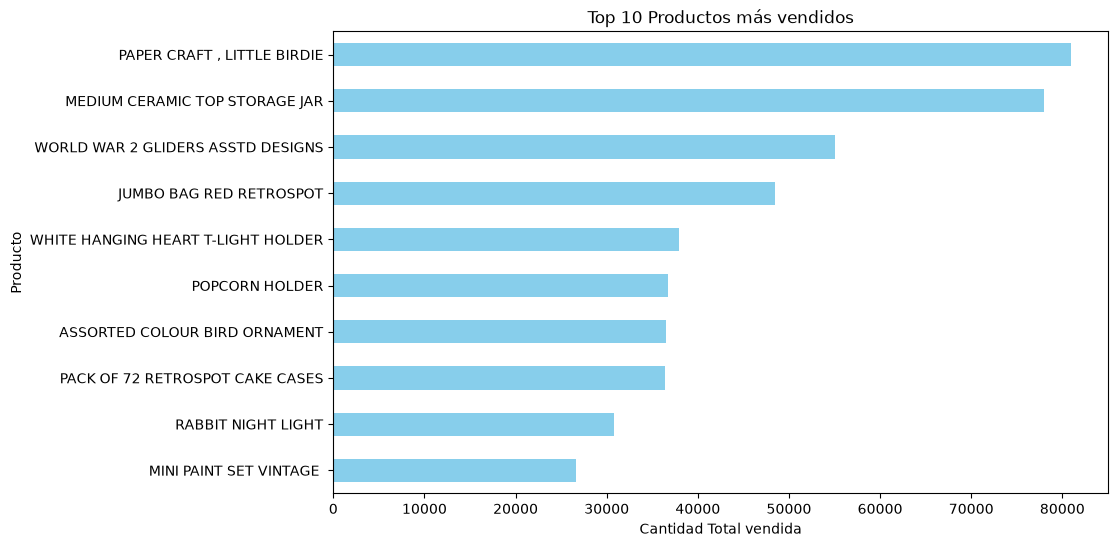

In [25]:
#Segmento que se vende más
df_limpio = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0) & (df['UnitPrice'] < 5000)]

top_productos = df_limpio.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

# 3. Visualización del Top 10
plt.figure(figsize=(10, 6))
top_productos.plot(kind='barh', color='skyblue')
plt.title('Top 10 Productos más vendidos')
plt.xlabel('Cantidad Total vendida')
plt.ylabel('Producto')
plt.gca().invert_yaxis() # Para que el #1 quede arriba
plt.show()

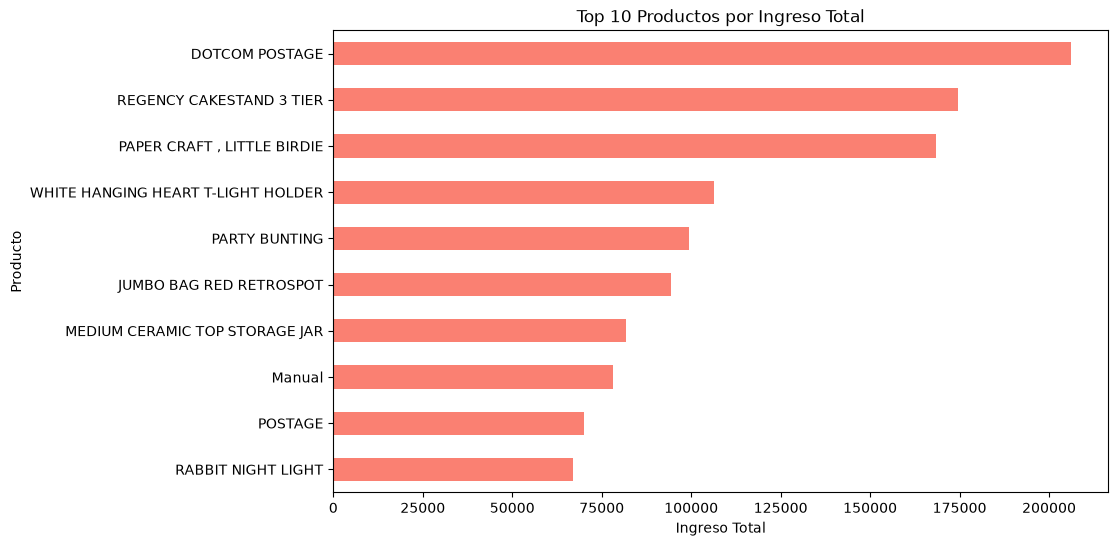

In [ ]:
#Segmento que deja más ingresos
df_limpio['Ingreso'] = df_limpio['Quantity'] * df_limpio['UnitPrice']

top_ingresos = df_limpio.groupby('Description')['Ingreso'].sum().sort_values(ascending=False).head(10)

# 3. Graficar (igual que el anterior, cambiando 'Ingreso')
plt.figure(figsize=(10, 6))
top_ingresos.plot(kind='barh', color='salmon')
plt.title('Top 10 Productos por Ingreso Total')
plt.xlabel('Ingreso Total')
plt.ylabel('Producto')
plt.gca().invert_yaxis()
plt.show()